# Experiment 6: Dual-Head U-Net for Mask + Skeleton Learning 
## Objective

####  The objective of this experiment is to improve ship segmentation performance by introducing a Dual-Head U-Net architecture that simultaneously learns:

* Segmentation masks (ship regions)
* Skeleton representations (centerlines / structural features)



## 1. Libraries & Dependencies
#### This section imports all required libraries for:

* Deep learning (PyTorch)
* Data handling (NumPy, Rasterio)
* Data augmentation (Albumentations)
* Image processing (OpenCV, SciPy)
* Visualization (Matplotlib)

#### Compared to previous experiments, this setup introduces additional libraries to support skeleton generation and structural learning, which are essential for the Dual-Head U-Net architecture.

In [1]:

# 1. Libraries & Dependencies

import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import rasterio
import albumentations as A
import cv2
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt
import random

/dss/dsshome1/0F/di54cak/geo-oma-24/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Configuration
#### Defines key experiment settings:
* Dataset paths
* Batch size and validation split
* Training parameters (epochs, learning rate)
* Device selection (CPU/GPU)
* Skeleton loss weighting (lambda_skel)

#### Introduces multi-task learning control, where the total loss combines segmentation and skeleton supervision.

In [3]:

# 2. Configuration

config = {
    "data": {
        "root": "/dss/dsshome1/0F/di54cak/geo-oma-24/temesghen_ship_detection_notebook/data/Patches",
        "img_dir": "images",
        "mask_dir": "masks",
        "batch_size": 8,
        "num_workers": 2,
        "val_split": 0.2,
    },
    "training": {
        "epochs": 50,
        "lr": 1e-3,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "lambda_skel": 0.3
    },
    "outputs": {
        "save_dir": "outputs"
    }
}

os.makedirs(config["outputs"]["save_dir"], exist_ok=True)
print("Using device:", config["training"]["device"])

Using device: cpu


## 3. Dataset Class
#### Handles:
* Reading SAR images (VV & VH channels)
* Clipping values to −25, 10
* Normalizing to 0,1
* Loading segmentation masks
* Generating distance maps
* Generating skeleton representations
* Applying augmentation

#### Extends the dataset pipeline by including structural information (distance map + skeleton), enabling the model to learn both region and shape features.

In [4]:

# 3. Dataset Class

class ShipDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # Read SAR image (VV + VH)
        with rasterio.open(self.img_paths[idx]) as src:
            vv = src.read(1).astype(np.float32)
            vh = src.read(2).astype(np.float32)
            img = np.stack([vv, vh], axis=-1)
            img = np.clip(img, -25, 10)
            img = (img + 25.0) / 35.0

        # Read mask
        with rasterio.open(self.mask_paths[idx]) as src:
            mask = src.read(1).astype(np.float32)
            if mask.max() > 0:
                mask = mask / mask.max()
            mask = np.expand_dims(mask, -1)

        # Placeholder distance map & skeleton (computed later)
        dist = np.expand_dims(compute_distance_map(mask.squeeze()), -1)
        skel = np.expand_dims(compute_skeleton(mask.squeeze()), -1)

        # Concatenate image + distance + skeleton as input
        img = np.concatenate([img, dist, skel], axis=-1)

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]

        img = torch.from_numpy(img).permute(2,0,1).float()
        mask = torch.from_numpy(mask).permute(2,0,1).float()
        skel = torch.from_numpy(skel).permute(2,0,1).float()
        return img, mask, skel

# 4. Feature Engineering
#### Handles:
* Computing distance maps from segmentation masks
* Generating skeleton representations using edge detection
* Normalizing structural features

#### Introduces structure-aware features (distance + skeleton) that help the model learn object shape and geometry, not just pixel-wise regions.

In [5]:

# 4. Feature Engineering

def compute_distance_map(mask):
    binary = (mask > 0.5).astype(np.uint8)
    dist = distance_transform_edt(binary)
    if dist.max() > 0:
        dist = dist / dist.max()
    return dist

def compute_skeleton(mask):
    binary = (mask > 0.5).astype(np.uint8)
    edges = cv2.Canny(binary * 255, 50, 150)
    return edges.astype(np.float32) / 255.0

# 5. Dataloaders
#### Handles:
* Splitting dataset into training and validation sets
* Applying data augmentation to training data
* Creating PyTorch DataLoaders for batching
* Shuffling training data for better generalization

#### Maintains the same data pipeline while supporting multi-input features (image + distance + skeleton) for training the Dual-Head model.

In [6]:

# 5. Dataloaders

def get_dataloaders(cfg):
    img_dir = os.path.join(cfg["data"]["root"], cfg["data"]["img_dir"])
    mask_dir = os.path.join(cfg["data"]["root"], cfg["data"]["mask_dir"])

    imgs = sorted(glob.glob(os.path.join(img_dir, "*.tif")))
    masks = sorted(glob.glob(os.path.join(mask_dir, "*.tif")))

    split = int((1 - cfg["data"]["val_split"]) * len(imgs))
    train_imgs, val_imgs = imgs[:split], imgs[split:]
    train_masks, val_masks = masks[:split], masks[split:]

    train_tf = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=30, p=0.5),
        A.RandomBrightnessContrast(p=0.3)
    ])

    train_ds = ShipDataset(train_imgs, train_masks, train_tf)
    val_ds = ShipDataset(val_imgs, val_masks, None)

    train_loader = DataLoader(train_ds, batch_size=cfg["data"]["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg["data"]["batch_size"], shuffle=False)

    return train_loader, val_loader

train_loader, val_loader = get_dataloaders(config)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 50
Val batches: 13


In [7]:
def compute_distance_map(mask):
    binary = (mask > 0.5).astype(np.uint8)
    dist = distance_transform_edt(binary)
    if dist.max() > 0:
        dist = dist / dist.max()
    return dist


def compute_skeleton(mask):
    binary = (mask > 0.5).astype(np.uint8)
    edges = cv2.Canny(binary * 255, 50, 150)
    return edges.astype(np.float32) / 255.0

# 6. Sample Visualization
#### Handles:
* Visualizing SAR input channels (VV, VH)
* Displaying ground truth segmentation mask
* Showing skeleton ground truth
* Visualizing engineered features (distance map + skeleton input)
#### This step helps verify that feature engineering is correctly applied and that both structural and spectral information are properly included in the model input.

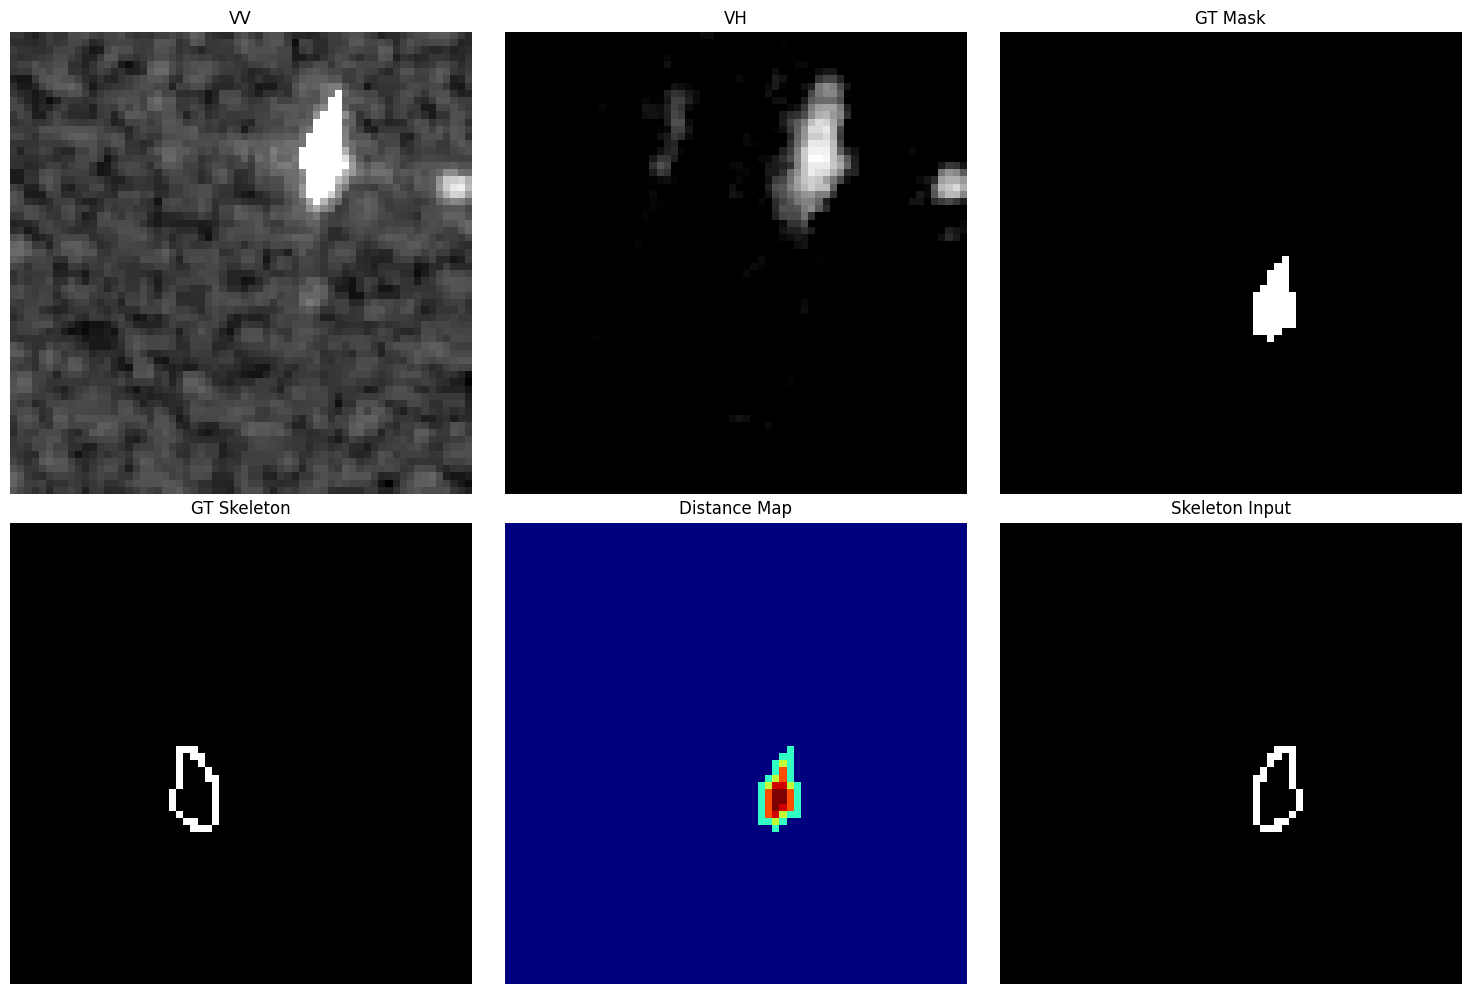

In [8]:

# 6. Sample Visualization (2 rows x 3 cols)

img, mask, skel = next(iter(train_loader))

fig, axs = plt.subplots(2,3, figsize=(15,10))
axs = axs.flatten()

# Row 1
axs[0].imshow(img[0,0], cmap='gray'); axs[0].set_title("VV")
axs[1].imshow(img[0,1], cmap='gray'); axs[1].set_title("VH")
axs[2].imshow(mask[0,0], cmap='gray'); axs[2].set_title("GT Mask")

# Row 2
axs[3].imshow(skel[0,0], cmap='gray'); axs[3].set_title("GT Skeleton")
axs[4].imshow(img[0,2], cmap='jet'); axs[4].set_title("Distance Map")
axs[5].imshow(img[0,3], cmap='gray'); axs[5].set_title("Skeleton Input")

for ax in axs:
    ax.axis("off")
plt.tight_layout()
plt.show()

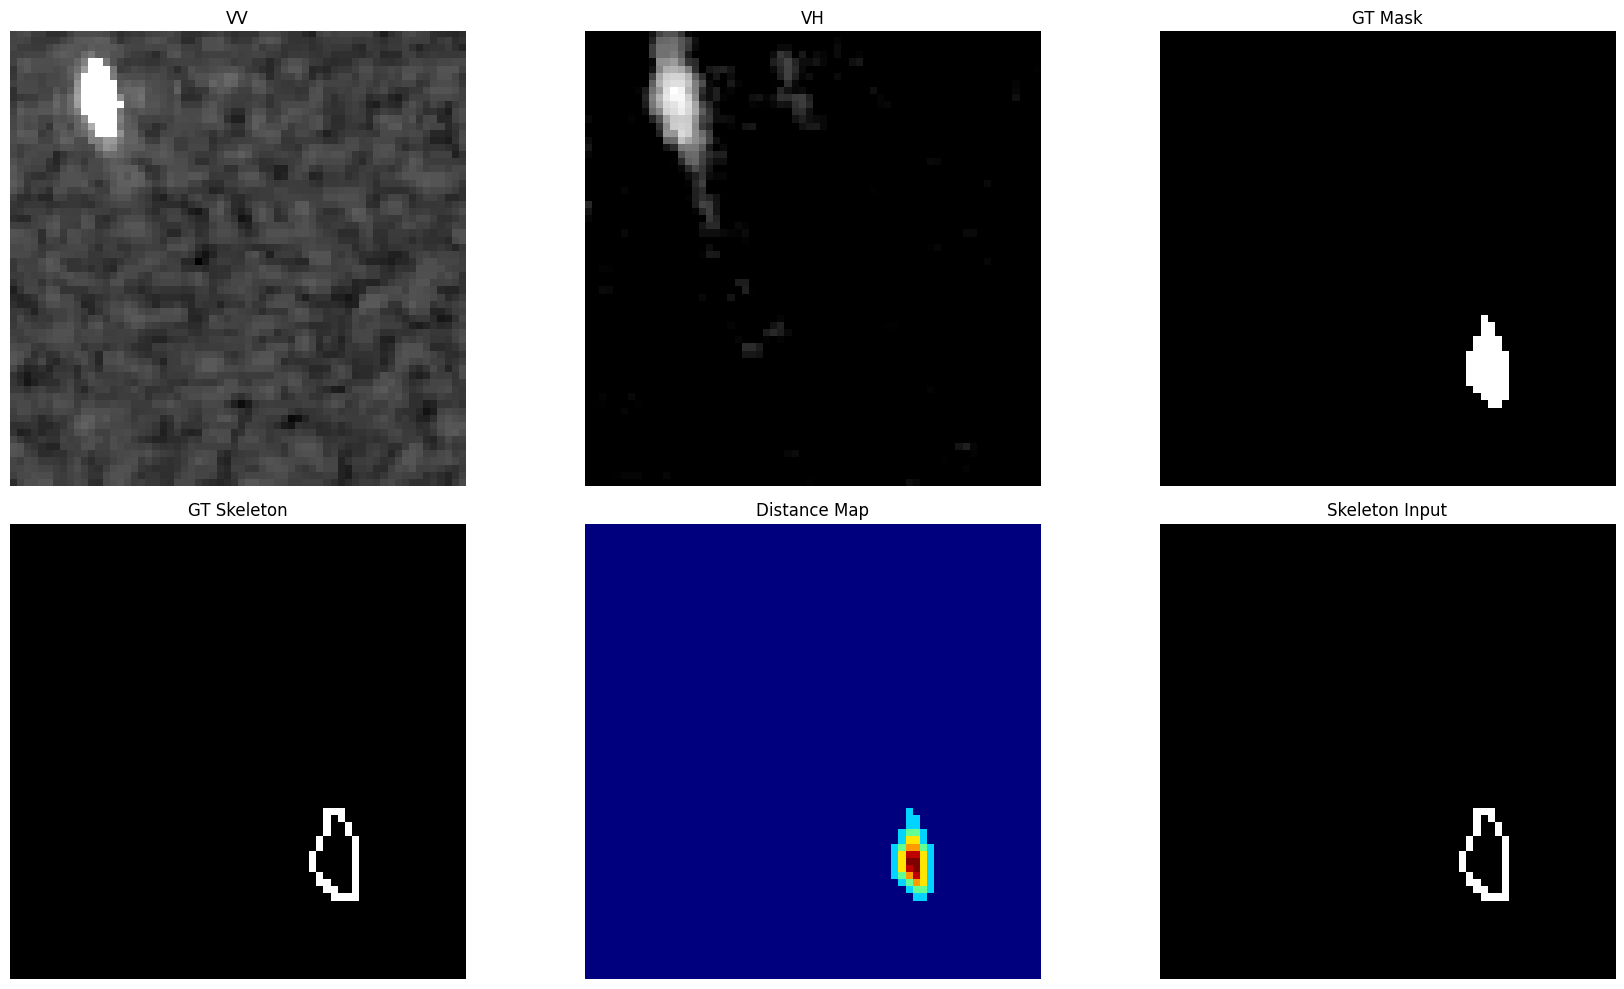

In [9]:
img, mask, skel = next(iter(train_loader))

fig, axs = plt.subplots(2, 3, figsize=(18, 10))  # 2 rows, 3 columns
axs = axs.flatten()

# Row 1
axs[0].imshow(img[0,0], cmap='gray'); axs[0].set_title("VV")
axs[1].imshow(img[0,1], cmap='gray'); axs[1].set_title("VH")
axs[2].imshow(mask[0,0], cmap='gray'); axs[2].set_title("GT Mask")

# Row 2
axs[3].imshow(skel[0,0], cmap='gray'); axs[3].set_title("GT Skeleton")
axs[4].imshow(img[0,2], cmap='jet'); axs[4].set_title("Distance Map")
axs[5].imshow(img[0,3], cmap='gray'); axs[5].set_title("Skeleton Input")

# Turn off axes
for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()

# 7. Model Architecture — Dual-Head U-Net
#### Handles:
* Building a U-Net encoder–decoder backbone
* Extracting hierarchical feature representations
* Splitting into two prediction heads:
* Segmentation mask head
* Skeleton structure head
#### Producing pixel-wise outputs for both tasks

#### This is the core innovation of this experiment, where the model performs multi-task learning by jointly predicting:

* Ship regions (segmentation)
* Structural shape (skeleton)

#### This helps the network learn both where the ship is and how it is structured.

In [10]:

# 7. Model Architecture — Dual Head UNet

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)

class DualHeadUNet(nn.Module):
    def __init__(self, in_channels=4, base=32):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base*2)
        self.enc3 = DoubleConv(base*2, base*4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base*4, base*8)
        # Up-sampling
        self.up1 = nn.ConvTranspose2d(base*8, base*4, 2,2)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2,2)
        self.up3 = nn.ConvTranspose2d(base*2, base, 2,2)
        # Segmentation head
        self.dec1_seg = DoubleConv(base*8, base*4)
        self.dec2_seg = DoubleConv(base*4, base*2)
        self.dec3_seg = DoubleConv(base*2, base)
        self.out_seg = nn.Conv2d(base, 1, 1)
        # Skeleton head
        self.dec1_skel = DoubleConv(base*8, base*4)
        self.dec2_skel = DoubleConv(base*4, base*2)
        self.dec3_skel = DoubleConv(base*2, base)
        self.out_skel = nn.Conv2d(base,1,1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))

        # Segmentation path
        u1 = self.up1(b)
        s1 = self.dec1_seg(torch.cat([u1,e3],1))
        u2 = self.up2(s1)
        s2 = self.dec2_seg(torch.cat([u2,e2],1))
        u3 = self.up3(s2)
        s3 = self.dec3_seg(torch.cat([u3,e1],1))
        pred_mask = torch.sigmoid(self.out_seg(s3))

        # Skeleton path
        k1 = self.dec1_skel(torch.cat([u1,e3],1))
        k2 = self.dec2_skel(torch.cat([u2,e2],1))
        k3 = self.dec3_skel(torch.cat([u3,e1],1))
        pred_skel = torch.sigmoid(self.out_skel(k3))

        return pred_mask, pred_skel

# 8. Metrics & Loss
#### Handles:
* Defining the Binary Cross Entropy (BCE) loss function
* Computing Dice Coefficient for segmentation quality
* Computing Intersection over Union (IoU) score
* Evaluating pixel-wise prediction performance

#### These metrics are used to evaluate the quality of both segmentation and structural learning in the Dual-Head U-Net.

In [11]:

# 8. Metrics & Loss

bce = nn.BCELoss()

def dice_coef(pred, target, smooth=1e-6):
    pred = (pred>0.5).float()
    inter = (pred*target).sum()
    return (2*inter + smooth)/(pred.sum()+target.sum()+smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = (pred>0.5).float()
    inter = (pred*target).sum()
    union = pred.sum() + target.sum() - inter
    return (inter + smooth)/(union + smooth)

# 9. Training Loop — Dual-Head U-Net
#### Handles:
* Training the Dual-Head U-Net model
* Optimizing both segmentation and skeleton tasks simultaneously
* Computing weighted multi-task loss
* Tracking performance metrics over epochs
* Evaluating model on validation set
#### This is the core training stage where the model learns both object regions and structural information jointly.

In [12]:

# 9. Training Loop (Dual-Head UNet)

model = DualHeadUNet().to(config["training"]["device"])
opt = optim.Adam(model.parameters(), lr=config["training"]["lr"])
bce = nn.BCELoss()  # BCE loss for both mask and skeleton

# History lists
train_loss_hist, val_loss_hist = [], []
train_bce_hist, val_bce_hist = [], []
train_skel_bce_hist, val_skel_bce_hist = [], []  # Skeleton BCE history
train_dice_hist, val_dice_hist = [], []
train_iou_hist, val_iou_hist = [], []

# Start training
for epoch in range(config["training"]["epochs"]):
    model.train()
    tl, tbce, tsbce, td, ti = 0,0,0,0,0  # Initialize accumulators

    # Training

    for img, mask, skel in train_loader:
        img, mask, skel = img.to(config["training"]["device"]), mask.to(config["training"]["device"]), skel.to(config["training"]["device"])
        pred_mask, pred_skel = model(img)  # Dual-head outputs

        # Compute losses
        loss_mask = bce(pred_mask, mask)
        loss_skel = bce(pred_skel, skel)
        loss = loss_mask + config["training"]["lambda_skel"] * loss_skel  # Weighted combination

        # Backpropagation
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Accumulate metrics
        tl += loss.item()
        tbce += loss_mask.item()
        tsbce += loss_skel.item()
        td += dice_coef(pred_mask, mask).item()
        ti += iou_score(pred_mask, mask).item()

    
    # Validation
    
    model.eval()
    vl, vbce, vsbce, vd, vi = 0,0,0,0,0
    with torch.no_grad():
        for img, mask, skel in val_loader:
            img, mask, skel = img.to(config["training"]["device"]), mask.to(config["training"]["device"]), skel.to(config["training"]["device"])
            pred_mask, pred_skel = model(img)

            # Compute losses
            loss_mask = bce(pred_mask, mask)
            loss_skel = bce(pred_skel, skel)
            loss = loss_mask + config["training"]["lambda_skel"] * loss_skel

            # Accumulate metrics
            vl += loss.item()
            vbce += loss_mask.item()
            vsbce += loss_skel.item()
            vd += dice_coef(pred_mask, mask).item()
            vi += iou_score(pred_mask, mask).item()

    
    # Save metrics
    
    train_loss_hist.append(tl/len(train_loader))
    val_loss_hist.append(vl/len(val_loader))
    train_bce_hist.append(tbce/len(train_loader))
    val_bce_hist.append(vbce/len(val_loader))
    train_skel_bce_hist.append(tsbce/len(train_loader))
    val_skel_bce_hist.append(vsbce/len(val_loader))
    train_dice_hist.append(td/len(train_loader))
    val_dice_hist.append(vd/len(val_loader))
    train_iou_hist.append(ti/len(train_loader))
    val_iou_hist.append(vi/len(val_loader))

    
    # Print metrics
    
    print(f"Epoch {epoch+1}: "
          f"Train Loss={train_loss_hist[-1]:.4f}, Val Loss={val_loss_hist[-1]:.4f}, "
          f"Train Mask BCE={train_bce_hist[-1]:.4f}, Val Mask BCE={val_bce_hist[-1]:.4f}, "
          f"Train Skel BCE={train_skel_bce_hist[-1]:.4f}, Val Skel BCE={val_skel_bce_hist[-1]:.4f}, "
          f"Train Dice={train_dice_hist[-1]:.4f}, Val Dice={val_dice_hist[-1]:.4f}, "
          f"Train IoU={train_iou_hist[-1]:.4f}, Val IoU={val_iou_hist[-1]:.4f}")

Epoch 1: Train Loss=0.6420, Val Loss=0.4584, Train Mask BCE=0.5156, Val Mask BCE=0.3631, Train Skel BCE=0.4215, Val Skel BCE=0.3178, Train Dice=0.4868, Val Dice=0.8514, Train IoU=0.3859, Val IoU=0.7422
Epoch 2: Train Loss=0.3595, Val Loss=0.2618, Train Mask BCE=0.2952, Val Mask BCE=0.2132, Train Skel BCE=0.2143, Val Skel BCE=0.1620, Train Dice=0.8699, Val Dice=0.9283, Train IoU=0.7710, Val IoU=0.8666
Epoch 3: Train Loss=0.2279, Val Loss=0.1535, Train Mask BCE=0.1898, Val Mask BCE=0.1255, Train Skel BCE=0.1271, Val Skel BCE=0.0931, Train Dice=0.9052, Val Dice=0.9478, Train IoU=0.8277, Val IoU=0.9010
Epoch 4: Train Loss=0.1516, Val Loss=0.1101, Train Mask BCE=0.1260, Val Mask BCE=0.0907, Train Skel BCE=0.0854, Val Skel BCE=0.0647, Train Dice=0.9171, Val Dice=0.9608, Train IoU=0.8478, Val IoU=0.9249
Epoch 5: Train Loss=0.1041, Val Loss=0.0740, Train Mask BCE=0.0851, Val Mask BCE=0.0605, Train Skel BCE=0.0634, Val Skel BCE=0.0449, Train Dice=0.9250, Val Dice=0.9703, Train IoU=0.8613, Val I

# 10. Training Curves Visualization
#### Handles:
* Visualizing model learning progress over epochs
* Tracking loss convergence
* Monitoring segmentation quality improvements
* Comparing training vs validation performance

#### These plots help evaluate whether the model is learning effectively or overfitting


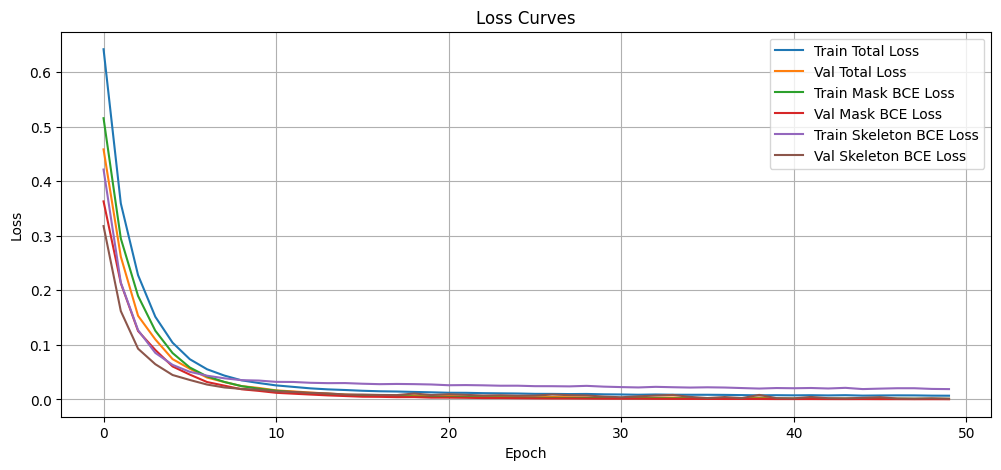

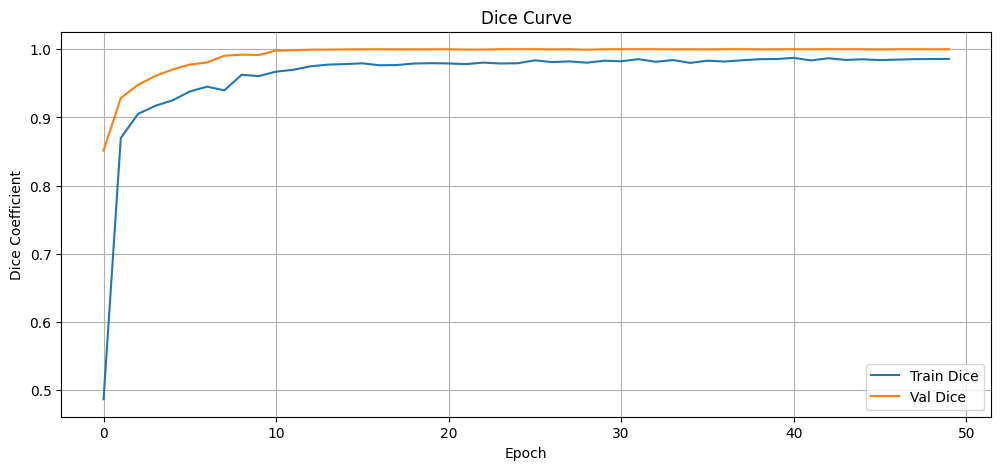

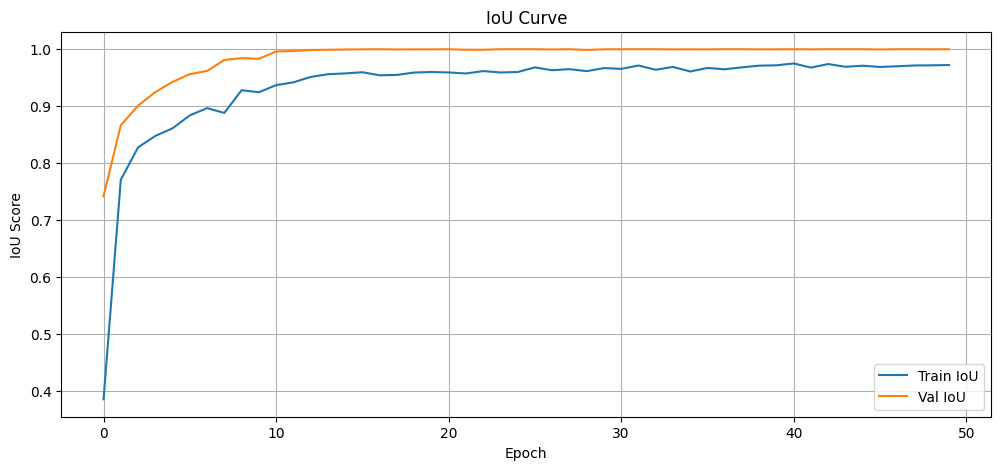

In [13]:

# 10. Plot Training Curves

# Total Loss + BCE Loss
plt.figure(figsize=(12,5))
plt.plot(train_loss_hist,label="Train Total Loss")
plt.plot(val_loss_hist,label="Val Total Loss")
plt.plot(train_bce_hist,label="Train Mask BCE Loss")
plt.plot(val_bce_hist,label="Val Mask BCE Loss")
plt.plot(train_skel_bce_hist,label="Train Skeleton BCE Loss")
plt.plot(val_skel_bce_hist,label="Val Skeleton BCE Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Dice Curve
plt.figure(figsize=(12,5))
plt.plot(train_dice_hist,label="Train Dice")
plt.plot(val_dice_hist,label="Val Dice")
plt.title("Dice Curve")
plt.xlabel("Epoch")
plt.ylabel("Dice Coefficient")
plt.legend()
plt.grid(True)
plt.show()

# IoU Curve
plt.figure(figsize=(12,5))
plt.plot(train_iou_hist,label="Train IoU")
plt.plot(val_iou_hist,label="Val IoU")
plt.title("IoU Curve")
plt.xlabel("Epoch")
plt.ylabel("IoU Score")
plt.legend()
plt.grid(True)
plt.show()

## 11. Prediction Visualization

Using device: cpu


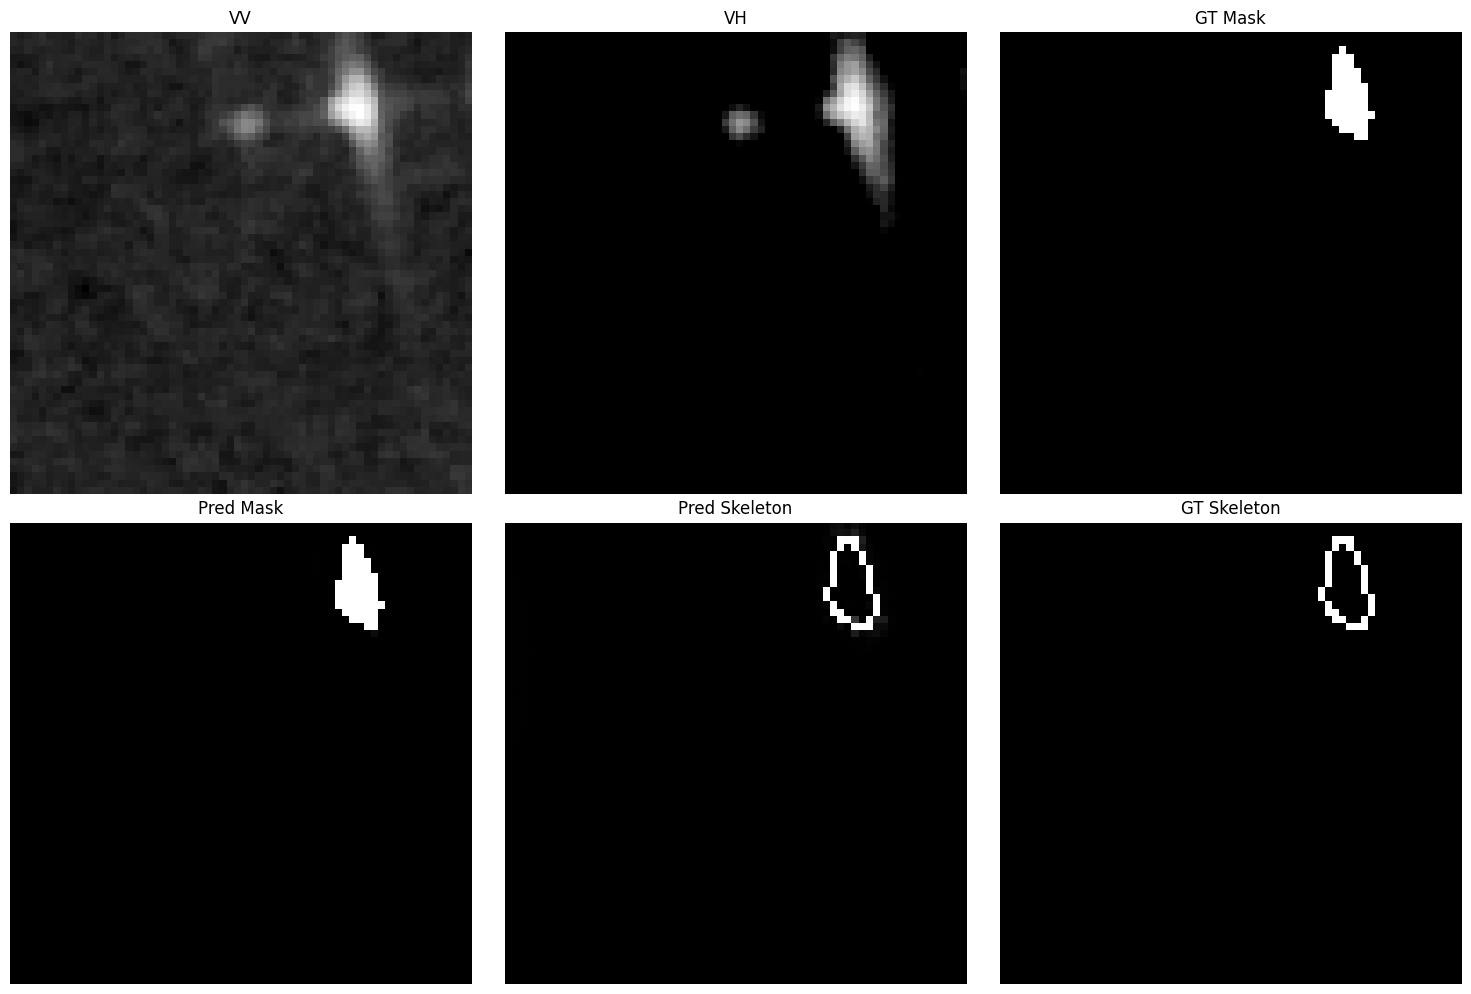

In [14]:

# 11. Visualize Predictions

# Add this line to define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

img, mask, skel = next(iter(val_loader))
img, mask, skel = img.to(device), mask.to(device), skel.to(device)

with torch.no_grad():
    pred_mask, pred_skel = model(img)

# Move predictions back to CPU for visualization
pred_mask = pred_mask.cpu()
pred_skel = pred_skel.cpu()
img = img.cpu()
mask = mask.cpu()
skel = skel.cpu()

fig, axs = plt.subplots(2,3, figsize=(15,10))
axs = axs.flatten()

# Row 1
axs[0].imshow(img[0,0], cmap='gray'); axs[0].set_title("VV")
axs[1].imshow(img[0,1], cmap='gray'); axs[1].set_title("VH")
axs[2].imshow(mask[0,0], cmap='gray'); axs[2].set_title("GT Mask")

# Row 2
axs[3].imshow(pred_mask[0,0], cmap='gray'); axs[3].set_title("Pred Mask")
axs[4].imshow(pred_skel[0,0], cmap='gray'); axs[4].set_title("Pred Skeleton")
axs[5].imshow(skel[0,0], cmap='gray'); axs[5].set_title("GT Skeleton")

for ax in axs:
    ax.axis("off")
plt.tight_layout()
plt.show()